In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src
import sys
sys.path.append("../../src/")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sbn
from matplotlib.ticker import ScalarFormatter
from scipy.stats import ks_2samp

In [4]:
races=pd.read_csv('../../dataset/preprocessedRaces.csv', sep=",")
placements=pd.read_csv('../../dataset/preprocessedPlacements.csv', sep=",")
cyclists=pd.read_csv('../../dataset/preprocessedCyclists.csv', sep=",")

In [5]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

## Feature selection

Reconstruction of the original dataset by merging the three dataset produced for the previous tasks. We do not include in the final dataset those columns excluded from the analysis due not resolved data quality issues or because of redundancy. 

In [ ]:
cyclists.drop(['AVG weighted position', 'AVG position Autumn', 'AVG position Spring', 'AVG position Summer', 'AVG position Winter', 'AVG position Q1', 'AVG position Q2', 'AVG position Q3', 'AVG position Q4'], axis=1, inplace=True)
cyclists.columns

In [ ]:
races.drop(['uci_points', 'average_temperature', 'is_tarmac', 'is_cobbled', 'is_gravel'], axis=1, inplace=True)
races.columns

Index(['_url', 'name', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'date', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

In [8]:
placements.drop(['cyclist_team'], axis=1, inplace=True)
placements.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', 'date', '_url', 'year'], dtype='object')

In [9]:
placements.head()

,position,cyclist,cyclist_age,delta,date,_url,year
0,0,georges-pintens,24,0,1970-04-25,amstel-gold-race/1970/result,1970
1,1,willy-van-neste,26,0,1970-04-25,amstel-gold-race/1970/result,1970
2,2,andre-dierickx,23,22,1970-04-25,amstel-gold-race/1970/result,1970
3,3,eric-leman,24,33,1970-04-25,amstel-gold-race/1970/result,1970
4,4,joseph-schoeters,23,33,1970-04-25,amstel-gold-race/1970/result,1970


In [10]:
races.head()

,_url,name,points,length,climb_total,profile,startlist_quality,date,climb/length,median_delta,std_delta
0,tour-de-france/1978/stage-6,Tour de France,100,162000,1101,1,1241,1978-07-05,0.006796,27.0,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,196000,5575,5,821,2016-09-03,0.028444,1957.0,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100,128000,781,1,1699,2019-07-28,0.006102,29.0,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,8100,68,1,804,1999-06-17,0.008395,53.0,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100,192900,3743,3,1551,2022-07-10,0.019404,1376.0,675.354230


In [11]:
cyclists.head()

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,std_dev position
0,sean-kelly,23.770000,6,16,629,Ireland,Europe,Northern Europe,1956.0,24.497844
1,gerrie-knetemann,19.959003,38,48,271,Netherlands,Europe,Western Europe,1951.0,46.993017
2,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,32.648452
3,joseph-bruyere,23.086015,8,16,48,Belgium,Europe,Western Europe,1948.0,19.723611
4,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,26.276978


Reconstruction of the original dataset including the new features.

In [12]:
dataset=pd.merge(placements, races, how='inner', on='_url')
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', 'date_x', '_url', 'year',
       'name', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'date_y', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

In [13]:
dataset.drop(['date_y', 'date_x'], axis=1, inplace=True)

In [14]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'name',
       'points', 'length', 'climb_total', 'profile', 'startlist_quality',
       'climb/length', 'median_delta', 'std_delta'],
      dtype='object')

In [15]:
dataset=pd.merge(dataset, cyclists, how='inner', left_on='cyclist', right_on='name')

In [16]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'name_x',
       'points', 'length', 'climb_total', 'profile', 'startlist_quality',
       'climb/length', 'median_delta', 'std_delta', 'name_y', 'BMI',
       'median position', 'AVG position', '# cyclist races', 'nationality',
       'continent', 'geo area', 'birth_year', 'std_dev position'],
      dtype='object')

In [17]:
dataset.drop(['name_x', 'name_y'], axis=1, inplace=True)

In [18]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'points',
       'length', 'climb_total', 'profile', 'startlist_quality', 'climb/length',
       'median_delta', 'std_delta', 'BMI', 'median position', 'AVG position',
       '# cyclist races', 'nationality', 'continent', 'geo area', 'birth_year',
       'std_dev position'],
      dtype='object')

Actually we will use our model to predict the future placements (>=2022) of the cylists, for this reason we need to adjust some statistics of the cyclists which are calculated on the whole dataset, hence considering all the placements which are in the range (1970-2023). Moreover we need to exclude those columns that, in some sense, immediately allow us to assing the proper label (such as the _'position'_ but also the _'delta'_).

### Redefinition of the cyclist statistics

In [19]:
new_stats=pd.merge(placements, cyclists, left_on='cyclist', right_on='name', how='inner')

In [20]:
print(f"# of placements: {new_stats.shape[0]}")
print(f"# of placements >=2022: {new_stats[new_stats['year']>=2022].shape[0]}")

# of placements: 589865
# of placements >=2022: 35406


In [21]:
new_stats=new_stats[['cyclist','position', 'year']]
new_stats=new_stats[new_stats['year']<2022]
new_stats

,cyclist,position,year
0,georges-pintens,0,1970
1,willy-van-neste,1,1970
2,andre-dierickx,2,1970
3,eric-leman,3,1970
4,joseph-schoeters,4,1970
...,...,...,...
589757,johan-esteban-chaves,63,2021
589758,nelson-soto,64,2021
589759,pascal-eenkhoorn,65,2021
589760,nikias-arndt,66,2021


In [22]:
print(f"# of cyclists with placements <2022:{new_stats['cyclist'].unique().shape[0]}")

# of cyclists with placements <2022:5786


In [23]:
new_stats['median position'] = new_stats.groupby('cyclist')['position'].transform(lambda x: round(x.median()))
new_stats['AVG position'] = new_stats.groupby('cyclist')['position'].transform(lambda x: round(x.mean()))
new_stats['# cyclist races'] = new_stats.groupby('cyclist')['cyclist'].transform("count")

#We had to define this custom function because the default one did not work.
def custom_std(x):
    return x.std() if len(x) > 1 else 0
new_stats['std_dev position'] = new_stats.groupby('cyclist')['position'].transform(custom_std)

In [ ]:
print(new_stats.dtypes)
print(new_stats.isna().sum())

cyclist              object
position              int64
year                  int64
median position       int64
AVG position          int64
# cyclist races       int64
std_dev position    float64
dtype: object
cyclist             0
position            0
year                0
median position     0
AVG position        0
# cyclist races     0
std_dev position    0
dtype: int64


In [25]:
new_stats

,cyclist,position,year,median position,AVG position,# cyclist races,std_dev position
0,georges-pintens,0,1970,4,13,37,18.685480
1,willy-van-neste,1,1970,6,10,10,8.141116
2,andre-dierickx,2,1970,8,16,67,18.234961
3,eric-leman,3,1970,4,7,38,7.836705
4,joseph-schoeters,4,1970,19,20,7,9.860938
...,...,...,...,...,...,...,...
589757,johan-esteban-chaves,63,2021,33,45,373,37.031503
589758,nelson-soto,64,2021,140,118,33,47.450053
589759,pascal-eenkhoorn,65,2021,76,76,37,32.762477
589760,nikias-arndt,66,2021,88,88,343,50.876602


In [26]:
new_stats.drop(['position', 'year'], axis=1, inplace=True)
new_stats.drop_duplicates(inplace=True)
new_stats.shape[0]

5786

We notice that we have 5786 cyclists with informations related to the their races. These are less than the original number of cyclists because some of them have only participated in races after 2022 (comprised). Drop the columns containing the overall statistics and add the new stats.

In [27]:
dataset.drop(['AVG position', 'median position', '# cyclist races', 'std_dev position'], axis=1, inplace=True)

In [28]:
new_stats = new_stats.rename(columns={'median position': 'median position_2021', 
                                  'AVG position': 'AVG position_2021',
                                  '# cyclist races': '# cyclist races_2021',
                                  'std_dev position': 'std_dev position_2021'
                                  })

In [29]:
dataset

,position,cyclist,cyclist_age,delta,_url,year,points,length,climb_total,profile,startlist_quality,climb/length,median_delta,std_delta,BMI,nationality,continent,geo area,birth_year
0,0,georges-pintens,24,0,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,22.057578,Belgium,Europe,Western Europe,1946.0
1,1,willy-van-neste,26,0,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,18.646937,Belgium,Europe,Western Europe,1944.0
2,2,andre-dierickx,23,22,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,22.840000,Belgium,Europe,Western Europe,1947.0
3,3,eric-leman,24,33,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,21.748939,Belgium,Europe,Western Europe,1946.0
4,4,joseph-schoeters,23,33,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,22.727257,Belgium,Europe,Western Europe,1947.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589860,98,daan-hoole,23,688,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,20.760000,Netherlands,Europe,Western Europe,1999.0
589861,99,ben-turner,23,700,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,19.660000,Great Britain,Europe,Northern Europe,1999.0
589862,100,pavel-sivakov,25,868,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,19.810000,France,Europe,Western Europe,1997.0
589863,101,jake-stewart,23,905,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,20.600000,Great Britain,Europe,Northern Europe,1999.0


In [30]:
new_stats

,cyclist,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021
0,georges-pintens,4,13,37,18.685480
1,willy-van-neste,6,10,10,8.141116
2,andre-dierickx,8,16,67,18.234961
3,eric-leman,4,7,38,7.836705
4,joseph-schoeters,19,20,7,9.860938
...,...,...,...,...,...
589604,lucas-eriksson,64,64,2,28.284271
589669,jakub-otruba,63,63,1,0.000000
589676,adam-toupalik,70,70,1,0.000000
589689,torstein-traeen,83,83,1,0.000000


In [31]:
dataset['cyclist'] = dataset['cyclist'].astype(str)
new_stats['cyclist'] = new_stats['cyclist'].astype(str)

We need to perform a left join since some cyclists may not have races in years before 2022. In that case, the performance columns will have a NaN value.

In [32]:
dataset=pd.merge(dataset, new_stats, how='left', on='cyclist')

In [33]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'points',
       'length', 'climb_total', 'profile', 'startlist_quality', 'climb/length',
       'median_delta', 'std_delta', 'BMI', 'nationality', 'continent',
       'geo area', 'birth_year', 'median position_2021', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021'],
      dtype='object')

In [34]:
dataset.shape[0]

589865

In [35]:
#check if there is any null value
dataset.isna().sum()

position                    0
cyclist                     0
cyclist_age                 0
delta                       0
_url                        0
year                        0
points                      0
length                      0
climb_total                 0
profile                     0
startlist_quality           0
climb/length                0
median_delta                0
std_delta                   0
BMI                         0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
median position_2021     3615
AVG position_2021        3615
# cyclist races_2021     3615
std_dev position_2021    3615
dtype: int64

After this pre-processing step we have obtained a dataframe with column performances limited to 2021. For those cyclists without a race before 2022 these columns will have a NaN. Notice that not all the classifiers are able to deal with missing values, hence we need to careful consider this aspect. Basically we can manage this problem in two ways:
- Remove the rows with NaNs in the test set, that are likely to have these "problematic" cyclists. The models that cannot deal with NaNs are forced to operate only on cyclists for whom we know these statistics.
- Define models that do not take into account these columns. This would limit the attributes used to make the prediction, giving more weight to the characteristics of the race rather than the cyclists.

**NOTE SUI NAN**<br>
La gestione dei valori mancanti (NaN) nei classificatori dipende dal modello e dalla libreria utilizzata. Alcuni classificatori possono gestire i valori mancanti direttamente, mentre altri richiedono che tu li rimuova o li imputi prima dell'addestramento. <br>

**Gestione Diretta dei NaN** <br>
Alcuni algoritmi specifici possono gestire i valori mancanti senza bisogno di preprocessamento esplicito:
Alberi decisionali (e modelli basati su alberi come Random Forest, Gradient Boosting):
Molti implementano tecniche per trattare i valori mancanti, come il completamento automatico basato sui percorsi più probabili. Ad esempio: HistGradientBoosting di scikit-learn supporta direttamente i NaN.
Alcuni implementazioni di XGBoost e LightGBM gestiscono automaticamente i valori mancanti. <br>

**Classificatori che NON Gestiscono NaN** <br>
Molti modelli richiedono che i dati siano completi:
Regressione logistica, SVM, KNN, Reti neurali.

### Redundancy removal

In [36]:
df_num = dataset.select_dtypes(include=["number"])
c_pearson = df_num.corr(method="pearson")['position']
c_spearman = df_num.corr(method="spearman")['position']
c_kendall = df_num.corr(method="kendall")['position']

correlations = pd.DataFrame({
    "Pearson": c_pearson,
    "Spearman": c_spearman,
    "Kendall": c_kendall
})

# Print the results as a table
print("Correlations w.r.t position")
print(correlations)

Correlations w.r.t position
                        Pearson  Spearman   Kendall
position               1.000000  1.000000  1.000000
cyclist_age            0.011969  0.008854  0.006357
delta                  0.236165  0.430059  0.299313
year                   0.142047  0.126100  0.085413
points                -0.079768  0.015253  0.011450
length                -0.012024 -0.023251 -0.015373
climb_total           -0.022597 -0.019591 -0.013095
profile               -0.011462 -0.010994 -0.007947
startlist_quality      0.147667  0.144739  0.097527
climb/length          -0.021176 -0.017952 -0.011862
median_delta           0.006928  0.003716  0.003072
std_delta              0.016092  0.041405  0.027649
BMI                    0.052756  0.050602  0.034396
birth_year             0.137308  0.127335  0.086437
median position_2021   0.453708  0.449531  0.317213
AVG position_2021      0.463757  0.457255  0.319031
# cyclist races_2021  -0.125560 -0.123631 -0.082856
std_dev position_2021  0.155666  0.1

Clearly we have to remove from the rows the position, that the classification model has to *predict*, but also the _delta_ that can be in some sense "cheating".

In [37]:
dataset.drop(['delta', 'median_delta', 'std_delta'], axis=1, inplace=True)

Controlliamo le correlazioni per rimuovere le features correlate

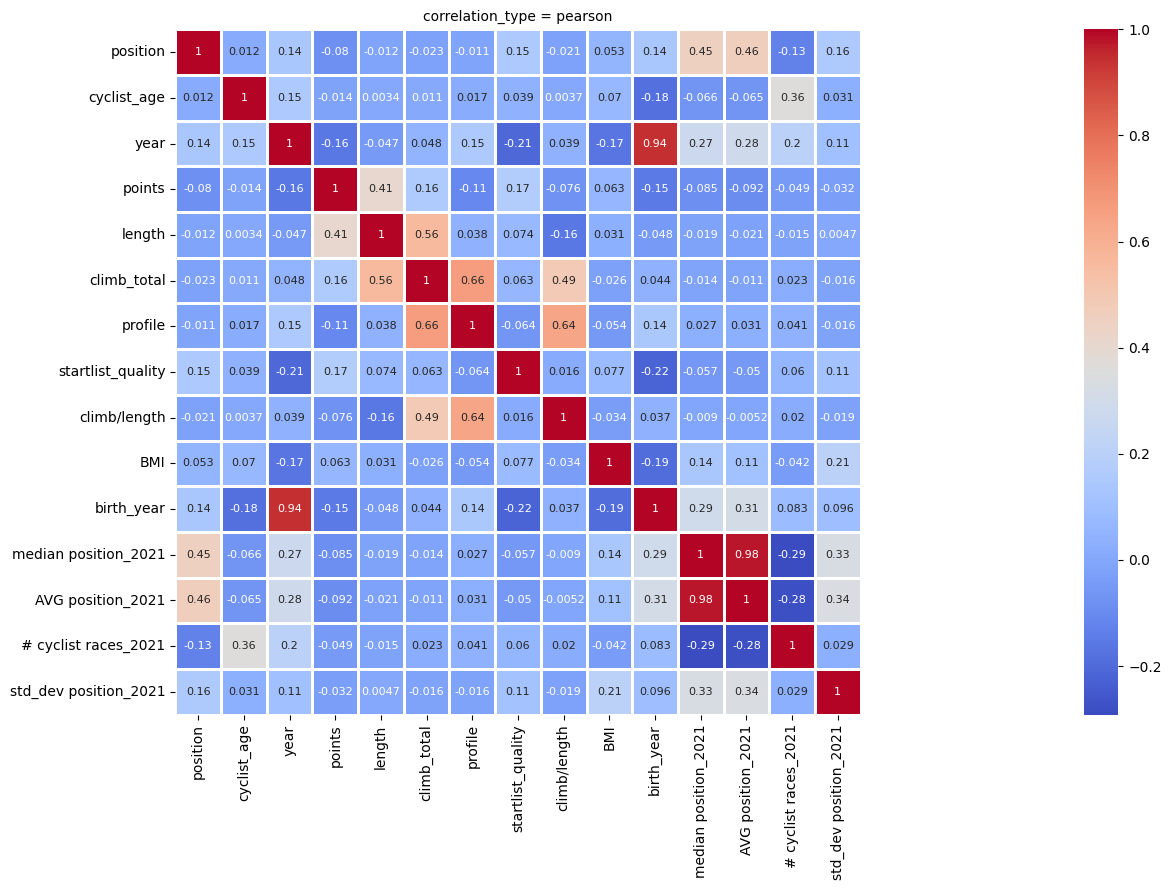

In [38]:
from distribution_utility import show_heatmap

show_heatmap(dataset, dataset.columns, 'pearson')

In [39]:
dataset.rename(columns={'year': 'race_year'}, inplace=True)
dataset.drop(['birth_year'], axis=1, inplace=True) #birth_year is redundant w.r.t race_year
dataset.drop(['median position_2021'], axis=1, inplace=True) 
# climb/lenght is redundant
# cyclist and url are identifiers
dataset.drop(['climb/length', 'cyclist', '_url'], axis=1, inplace=True)

#column rendundant w.r.t geo area
dataset.drop(['nationality', 'continent'], axis=1, inplace=True)

In [40]:
dataset.head()

,position,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,geo area,AVG position_2021,# cyclist races_2021,std_dev position_2021
0,0,24,1970,225,240000,2611,2,372,22.057578,Western Europe,13.0,37.0,18.685480
1,1,26,1970,225,240000,2611,2,372,18.646937,Western Europe,10.0,10.0,8.141116
2,2,23,1970,225,240000,2611,2,372,22.840000,Western Europe,16.0,67.0,18.234961
3,3,24,1970,225,240000,2611,2,372,21.748939,Western Europe,7.0,38.0,7.836705
4,4,23,1970,225,240000,2611,2,372,22.727257,Western Europe,20.0,7.0,9.860938


Let's generate the *class binary label* TOP20, which takes 1 as value if the position of the placement is in the range [0, 19], 0 otherwise.

In [41]:
dataset['top20'] = (dataset['position'] < 20).astype(int)

In [42]:
dataset[['top20', 'position']]

,top20,position
0,1,0
1,1,1
2,1,2
3,1,3
4,1,4
...,...,...
589860,0,98
589861,0,99
589862,0,100
589863,0,101


La levo perchè è la feateure da predire

In [43]:
dataset.drop(['position'], axis=1, inplace=True)

In [44]:
dataset.columns

Index(['cyclist_age', 'race_year', 'points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'BMI', 'geo area', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021', 'top20'],
      dtype='object')

### Feature encoding for non distance method

In [45]:
#input: the dataset and the list of variables' names to encode
def categorical_columns_encoding(dataset, variables):
    dataset = dataset.copy()
    for variable in variables:
        #get the unique variable's values
        var = sorted(dataset[variable].unique())
        
        #generate a mapping from the variable's values to the number representation  
        mapping = dict(zip(var, range(0, len(var) + 1)))

        print(f"Mapping of {variable}:", mapping)
        #add a new colum with the number representation of the variable
        dataset[variable+'_num'] = dataset[variable].map(mapping).astype(int)
    return dataset

In [46]:
categorical_columns = ['geo area']
dataset_for_non_distance = categorical_columns_encoding(dataset, categorical_columns)

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


### Feature encoding for distance method

In the classifiers that exploit the notion of distance, it's important to apply a preliminary normalization step so that we reduce the bias given by the range of the different attributes. In this case we use a standardization (z-score normalization). Let's retrieve the original dataset that we have to standardize and let's apply the one hot encoding to the geo area column.

In [54]:
dataset_for_distance = dataset.copy()
dataset_for_distance.head()

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,geo area,AVG position_2021,# cyclist races_2021,std_dev position_2021,top20
0,24,1970,225,240000,2611,2,372,22.057578,Western Europe,13.0,37.0,18.685480,1
1,26,1970,225,240000,2611,2,372,18.646937,Western Europe,10.0,10.0,8.141116,1
2,23,1970,225,240000,2611,2,372,22.840000,Western Europe,16.0,67.0,18.234961,1
3,24,1970,225,240000,2611,2,372,21.748939,Western Europe,7.0,38.0,7.836705,1
4,23,1970,225,240000,2611,2,372,22.727257,Western Europe,20.0,7.0,9.860938,1


In [55]:
# Remove the profile column which is an ordinal
dataset_for_distance.drop(['profile'], axis=1, inplace=True)

In [49]:
dataset_for_distance.columns

Index(['cyclist_age', 'race_year', 'points', 'length', 'climb_total',
       'startlist_quality', 'BMI', 'geo area', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021', 'top20'],
      dtype='object')

In [50]:
dataset_for_distance.columns

Index(['cyclist_age', 'race_year', 'points', 'length', 'climb_total',
       'startlist_quality', 'BMI', 'geo area', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021', 'top20'],
      dtype='object')

In [58]:
scaler = StandardScaler()
columns_to_be_scaled = ['cyclist_age', 'race_year', 'points', 'length', 'climb_total',
       'startlist_quality', 'BMI', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021']
top20 = dataset_for_distance.pop('top20')
geo_area = dataset_for_distance.pop('geo area')
dataset_for_distance = pd.DataFrame(scaler.fit_transform(dataset_for_distance), columns=columns_to_be_scaled)
dataset_for_distance = pd.concat([dataset_for_distance.reset_index(drop=True), top20.reset_index(drop=True)], axis=1)
dataset_for_distance = pd.concat([dataset_for_distance.reset_index(drop=True), geo_area.reset_index(drop=True)], axis=1)

In [62]:
dataset_for_distance

,cyclist_age,race_year,points,length,climb_total,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,top20,geo area_Africa,geo area_America,geo area_Asia,geo area_Eastern Europe,geo area_Northern Europe,geo area_Oceania,geo area_Southern Europe,geo area_Western Europe
0,-1.163424,-3.151069,2.495224,1.134452,0.241609,-1.915888,0.687653,-2.690865,-1.319497,-2.784335,1,False,False,False,False,False,False,False,True
1,-0.644689,-3.151069,2.495224,1.134452,0.241609,-1.915888,-1.937249,-2.822463,-1.460453,-4.031347,1,False,False,False,False,False,False,False,True
2,-1.422792,-3.151069,2.495224,1.134452,0.241609,-1.915888,1.289822,-2.559267,-1.162879,-2.837615,1,False,False,False,False,False,False,False,True
3,-1.163424,-3.151069,2.495224,1.134452,0.241609,-1.915888,0.450118,-2.954061,-1.314276,-4.067348,1,False,False,False,False,False,False,False,True
4,-1.422792,-3.151069,2.495224,1.134452,0.241609,-1.915888,1.203052,-2.383804,-1.476114,-3.827955,1,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589860,-1.422792,1.379530,4.792425,1.551212,1.425467,-0.129172,-0.310991,NaN,NaN,NaN,0,False,False,False,False,False,False,False,True
589861,-1.422792,1.379530,4.792425,1.551212,1.425467,-0.129172,-1.157575,NaN,NaN,NaN,0,False,False,False,False,True,False,False,False
589862,-0.904057,1.379530,4.792425,1.551212,1.425467,-0.129172,-1.042131,-0.760763,-0.917512,-0.150237,0,False,False,False,False,False,False,False,True
589863,-1.422792,1.379530,4.792425,1.551212,1.425467,-0.129172,-0.434130,-0.278238,-1.429129,-0.500194,0,False,False,False,False,True,False,False,False


In [60]:
dataset_for_distance = pd.get_dummies(dataset_for_distance, columns = ['geo area'], prefix_sep='_')

In [61]:
dataset_for_distance.head()

,cyclist_age,race_year,points,length,climb_total,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,top20,geo area_Africa,geo area_America,geo area_Asia,geo area_Eastern Europe,geo area_Northern Europe,geo area_Oceania,geo area_Southern Europe,geo area_Western Europe
0,-1.163424,-3.151069,2.495224,1.134452,0.241609,-1.915888,0.687653,-2.690865,-1.319497,-2.784335,1,False,False,False,False,False,False,False,True
1,-0.644689,-3.151069,2.495224,1.134452,0.241609,-1.915888,-1.937249,-2.822463,-1.460453,-4.031347,1,False,False,False,False,False,False,False,True
2,-1.422792,-3.151069,2.495224,1.134452,0.241609,-1.915888,1.289822,-2.559267,-1.162879,-2.837615,1,False,False,False,False,False,False,False,True
3,-1.163424,-3.151069,2.495224,1.134452,0.241609,-1.915888,0.450118,-2.954061,-1.314276,-4.067348,1,False,False,False,False,False,False,False,True
4,-1.422792,-3.151069,2.495224,1.134452,0.241609,-1.915888,1.203052,-2.383804,-1.476114,-3.827955,1,False,False,False,False,False,False,False,True


In [63]:
dataset.drop(categorical_columns, axis=1, inplace=True) #column already encoded

## Data segmentation: (Train - Test - Validation)

In [ ]:
original_size=dataset.shape[0]
test_set=dataset[dataset['race_year']>=2022]
train_set=dataset[dataset['race_year']<2022]
print(f"Test set size: {test_set.shape[0]} ({test_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Training set size: {train_set.shape[0]} ({train_set.shape[0] * 100 / original_size:.2f}%)")

Test set size: 35406 (6.00%)
Training set size: 554459 (94.00%)


In [ ]:
test_top20_counts = test_set['top20'].value_counts(normalize=True)
dataset_top20_counts = dataset['top20'].value_counts(normalize=True)

results = pd.DataFrame({
    'Test Set': test_top20_counts,
    'Training Set': dataset_top20_counts
})
print(results)

       Test Set  Training Set
top20                        
0      0.860476      0.837871
1      0.139524      0.162129


In [ ]:
train_label=dataset.pop('top20') 
test_label=test_set.pop('top20') #labels for the test set

### Undersampling
Under-sample the majority class by randomly picking samples with or without replacement. Notice that this strategy can exclude relevant data from the majority class.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# sampling_strategy --> if float, it is the desired ratio of the # of samples in the minority class over the # of 
#   samples in the majority class after resampling.
rand_undersampler=RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)

#Let's balance the classes with the proportion 0:60% - 1:40% (vs 87%-13% in the initial setting)
#40/60=0.67

In [ ]:
# The undersampling is done only on the training data! The validation set is used to assess the model
# learnt using this corrective strategy for an imbalanced setting
train_set_us, train_label_us = rand_undersampler.fit_resample(train_set, train_label)

top20
0    0.598801
1    0.401199
Name: proportion, dtype: float64


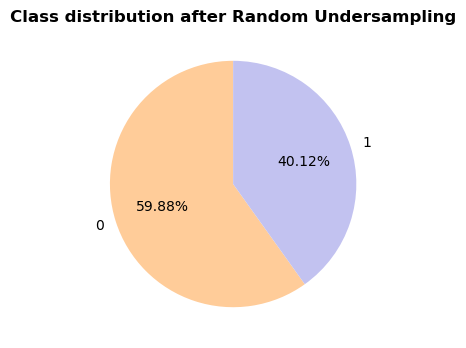

Initial training set size 388121. After undersampling 156845


In [ ]:
class_distribution = train_label_us.value_counts(normalize=True)
print(class_distribution)
plt.figure(figsize=(4, 4))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.2f%%', startangle=90, colors=["#ffcc99", "#c2c2f0"])
plt.title("Class distribution after Random Undersampling", fontweight='bold')
plt.show()
plt.close()
print(f"Initial training set size {train_label.shape[0]}. After undersampling {train_label_us.shape[0]}")

Actually this strategy has halved the data available for training the model.

In [ ]:
# KS Test on all the columns
test_results = [
    (column, ks_2samp(train_set[column], train_set_us[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: race_year, KS statistic: 0.0381, P-value: 0.0000
Column: points, KS statistic: 0.0139, P-value: 0.0000
Column: length, KS statistic: 0.0079, P-value: 0.0000
Column: climb_total, KS statistic: 0.0053, P-value: 0.0041
Column: profile, KS statistic: 0.0061, P-value: 0.0005
Column: startlist_quality, KS statistic: 0.0305, P-value: 0.0000
Column: BMI, KS statistic: 0.0120, P-value: 0.0000
Column: birth_year, KS statistic: 0.0375, P-value: 0.0000
Column: median position_2021, KS statistic: 0.0764, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0767, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0175, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0187, P-value: 0.0000
Column: geo area_num, KS statistic: 0.0047, P-value: 0.0157


In a previous iteration we have observed that the proportion 70:30 had an higher impact on the distribution. Also in this setting the distribution of some variables have been influenced. 

### Oversampling
Over-sample the minority class by picking samples at random with replacement.

#### Random oversampling

In [ ]:
from imblearn.over_sampling import RandomOverSampler

In [ ]:
# sampling_strategy --> if float, it is the desired ratio of the # of samples in the minority class over the # of 
#   samples in the majority class after resampling.
rand_oversampler=RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)

#Let's balance the classes with the proportion 0:60% - 1:40% (vs 87%-13% in the initial setting)
#40/60=0.67

In [ ]:
# The oversampling is done only on the training data! The validation set is used to assess the model
# learnt using this corrective strategy for an imbalanced setting
train_set_os, train_label_os = rand_oversampler.fit_resample(train_set, train_label)

top20
0    0.598803
1    0.401197
Name: proportion, dtype: float64


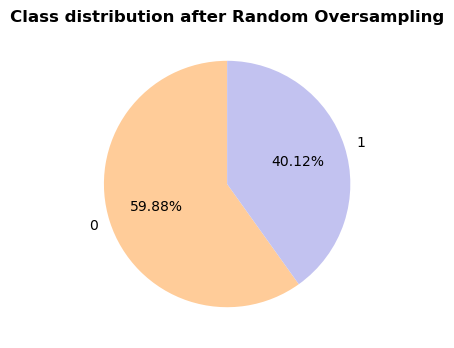

Initial training set size 388121. After undersampling 543075


In [ ]:
class_distribution = train_label_os.value_counts(normalize=True)
print(class_distribution)
plt.figure(figsize=(4, 4))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.2f%%', startangle=90, colors=["#ffcc99", "#c2c2f0"])
plt.title("Class distribution after Random Oversampling", fontweight='bold')
plt.show()
plt.close()
print(f"Initial training set size {train_label.shape[0]}. After undersampling {train_label_os.shape[0]}")

In this case the number of training samples is increased, since some instances of the minority class have been duplicated.

In [ ]:
# KS Test on all the columns
test_results = [
    (column, ks_2samp(train_set[column], train_set_os[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: race_year, KS statistic: 0.0388, P-value: 0.0000
Column: points, KS statistic: 0.0144, P-value: 0.0000
Column: length, KS statistic: 0.0071, P-value: 0.0000
Column: climb_total, KS statistic: 0.0044, P-value: 0.0003
Column: profile, KS statistic: 0.0056, P-value: 0.0000
Column: startlist_quality, KS statistic: 0.0296, P-value: 0.0000
Column: BMI, KS statistic: 0.0116, P-value: 0.0000
Column: birth_year, KS statistic: 0.0374, P-value: 0.0000
Column: median position_2021, KS statistic: 0.0768, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0769, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0164, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0184, P-value: 0.0000
Column: geo area_num, KS statistic: 0.0046, P-value: 0.0001


#### SMOTE: Synthetic Minority Oversampling Technique
The Synthetic Minority Over-Sampling Technique (SMOTE) is a used to handle class imbalance in datasets. SMOTE handles this issue by generating samples of minority classes to make the class distribution balanced. The algorithm uses an approach based on the K-NN classifier. So we need to perform the proper preprocessing.

In [ ]:
from imblearn.over_sampling import SMOTE

smote_oversampler = SMOTE(k_neighbors=3,sampling_strategy=0.67, random_state=RANDOM_STATE)

In [ ]:
train_set_smote, train_label_smote = smote_oversampler.fit_resample(train_set, train_label)

top20
0    0.598803
1    0.401197
Name: proportion, dtype: float64


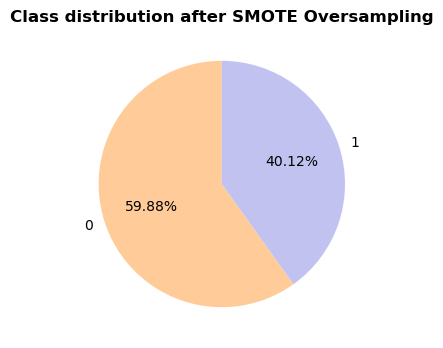

Initial training set size 388121. After undersampling 543075


In [ ]:
class_distribution = train_label_smote.value_counts(normalize=True)
print(class_distribution)
plt.figure(figsize=(4, 4))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.2f%%', startangle=90, colors=["#ffcc99", "#c2c2f0"])
plt.title("Class distribution after SMOTE Oversampling", fontweight='bold')
plt.show()
plt.close()
print(f"Initial training set size {train_label.shape[0]}. After undersampling {train_label_smote.shape[0]}")

In [ ]:
# KS Test on all the columns
test_results = [
    (column, ks_2samp(std_train_set[column], train_set_smote[column], alternative="two-sided"))
    for column in std_train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: points, KS statistic: 0.0237, P-value: 0.0000
Column: length, KS statistic: 0.0049, P-value: 0.0000
Column: climb_total, KS statistic: 0.0042, P-value: 0.0007
Column: startlist_quality, KS statistic: 0.0309, P-value: 0.0000
Column: BMI, KS statistic: 0.0112, P-value: 0.0000
Column: median position_2021, KS statistic: 0.0779, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0783, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0169, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0175, P-value: 0.0000
Column: geo area_num_0, KS statistic: 0.0008, P-value: 0.9991
Column: geo area_num_1, KS statistic: 0.0011, P-value: 0.9362
Column: geo area_num_2, KS statistic: 0.0012, P-value: 0.8876
Column: geo area_num_3, KS statistic: 0.0017, P-value: 0.4934
Column: geo area_num_4, KS statistic: 0.0034, P-value: 0.0095
Column: geo area_num_5, KS statistic: 0.0003, P-value: 1.0000
Column: geo area_num_6, KS statistic: 0.0008, P-value: 0.9991
Column: geo a

**TODO** Le colonne con differenze significative sono median_position, AVG position_2021, geo area_num. Levare le colonne ordinali, vedere se utile normalizzazione, separare già ad inizio notebook i vari preprocessing dei dati.

# Validation

The test set should never be used to perform the hyperparameter tuning and the model selection. Since we have a good number of training data, we decide to extract from it a specific _validation set_. In particular we perform a stratified train/test split in order to preserve the initial proportion between the two classes.

In [ ]:
# Extraction of the validation set (30% of the training data)
train_set_splitted, validation_set, train_label_splitted, validation_label = train_test_split(dataset, train_label, stratify = train_label, test_size=0.30, random_state=RANDOM_STATE)
training_top20_counts = train_label_splitted.value_counts(normalize=True)
validation_top20_counts = validation_label.value_counts(normalize=True)

results = pd.DataFrame({
    'Training Set': training_top20_counts,
    'Validation Set': validation_top20_counts,
    'Test Set': test_top20_counts
})
print(results)

print(f"Training set size: {train_set_splitted.shape[0]} ({train_set_splitted.shape[0] * 100 / original_size:.2f}%)")
print(f"Validation set size: {validation_set.shape[0]} ({validation_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Test set size: {test_set.shape[0]} ({test_set.shape[0] * 100 / original_size:.2f}%)")

       Training Set  Validation Set  Test Set
top20                                        
0           0.83787        0.837872  0.860476
1           0.16213        0.162128  0.139524
Training set size: 388121 (65.80%)
Validation set size: 166338 (28.20%)
Test set size: 35406 (6.00%)


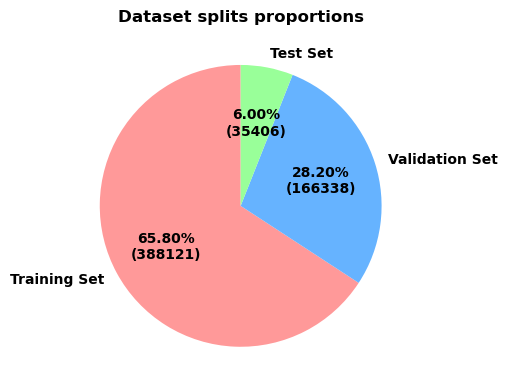

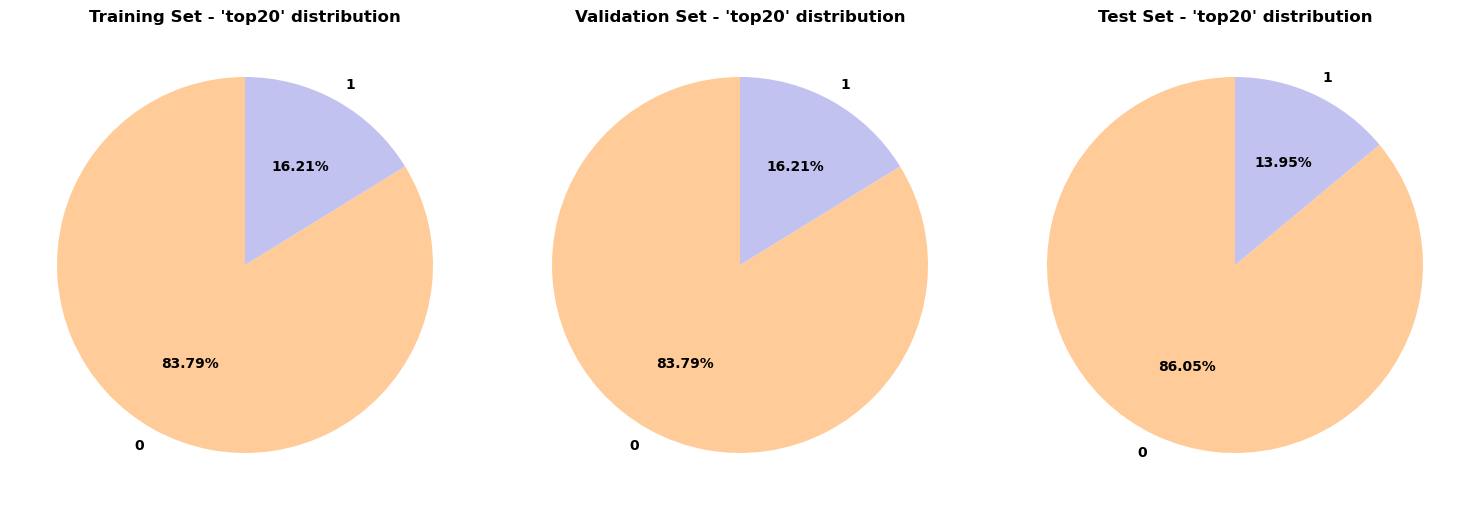

In [ ]:
#Set sizes
train_size = train_set_splitted.shape[0]
validation_size = validation_set.shape[0]
test_size = test_set.shape[0]
original_size = train_size + validation_size + test_size

# Pie plot for the set sizes
set_sizes = [train_size, validation_size, test_size]
set_labels = ["Training Set", "Validation Set", "Test Set"]
set_colors = ["#ff9999", "#66b3ff", "#99ff99"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(
    set_sizes,
    labels=set_labels,
    autopct=lambda p: f'{p:.2f}%\n({p*original_size/100:.0f})',
    startangle=90,
    colors=set_colors,
    textprops={'fontweight': 'bold'}
)
plt.title("Dataset splits proportions", fontweight='bold')

# Pie plot for the class distribution in the 3 partitions 
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

distributions = [training_top20_counts, validation_top20_counts, test_top20_counts]
titles = ["Training Set", "Validation Set", "Test Set"]
colors = [["#ffcc99", "#c2c2f0"], ["#ffcc99", "#c2c2f0"], ["#ffcc99", "#c2c2f0"]]

for ax, data, title, color in zip(axes, distributions, titles, colors):
    ax.pie(
        data,
        labels=data.index,
        autopct='%1.2f%%',
        startangle=90,
        colors=color,
        textprops={'fontweight': 'bold'}
    )
    ax.set_title(f"{title} - 'top20' distribution", fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

We immediately notice the fact that we are in an "unbalanced" context, with a minority '1' class.

In [ ]:
train_set.isna().sum()

race_year                0
points                   0
length                   0
climb_total              0
profile                  0
startlist_quality        0
BMI                      0
birth_year               0
median position_2021     0
AVG position_2021        0
# cyclist races_2021     0
std_dev position_2021    0
geo area_num             0
dtype: int64

In [ ]:
validation_set.isna().sum()

race_year                0
points                   0
length                   0
climb_total              0
profile                  0
startlist_quality        0
BMI                      0
birth_year               0
median position_2021     0
AVG position_2021        0
# cyclist races_2021     0
std_dev position_2021    0
geo area_num             0
dtype: int64

In [ ]:
test_set.isna().sum()

race_year                   0
points                      0
length                      0
climb_total                 0
profile                     0
startlist_quality           0
BMI                         0
birth_year                  0
median position_2021     3615
AVG position_2021        3615
# cyclist races_2021     3615
std_dev position_2021    3615
geo area_num                0
dtype: int64

Only the test set have some records with NaNs, for the reasons described above. Notice that there are 3615 with NaN statistics over 35406 total test set rows (about 10%).

Let's save the dataset and the data partitions because some classifiers require some pre-processing steps. In the saved version the 'geo area' column has been ecoded with a number. We decide to keep the geo area because it has a reasonable amount of values so, if we need to use the one hot encoding, we do not generate too many artificial columns. 

If required, the mapping 'geo area' --> 'geo area_num' has been printed in the coding function.

In [ ]:
# class_preprocessed_dataset has been saved before
class_preprocessed_train_set=train_set.copy()
class_preprocessed_validation_set=validation_set.copy()
class_preprocessed_test_set=test_set.copy()

For the usage of the grid search exploiting the **Cross Validation** technique, we need to use both training and validation data. For this reason we keep also a combined version of them. (train_set combina sia slitted che validation)